# 04 – Backtest Runner
Run every strategy against every ticker in your watchlist.  
Produces an equity-curve plot and a full metrics table.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from core.data_fetcher import get_data
from backtesting import BacktestEngine
from strategies import STRATEGY_REGISTRY

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

In [6]:
# ── Configuration ────────────────────────────────────────────────────────────
TICKERS = ['SHEL.L', 'AAPL']
PERIOD  = '2y'
CAPITAL = 10_000   # EUR

data = {t: get_data(t, source='yfinance', period=PERIOD) for t in TICKERS}
engine = BacktestEngine(initial_capital=CAPITAL)

In [7]:
# Run all strategies × all tickers, collect results
rows = []
for strat_name, cls in STRATEGY_REGISTRY.items():
    strategy = cls()
    for ticker in TICKERS:
        result = engine.run(strategy, data[ticker], ticker=ticker)
        row = {'strategy': strat_name, 'ticker': ticker}
        row.update(result.metrics)
        rows.append(row)

results_df = pd.DataFrame(rows).set_index(['strategy', 'ticker'])
results_df.style.background_gradient(cmap='RdYlGn', subset=['sharpe_ratio', 'total_return'])


Best for AAPL: rsi  Sharpe=0.33


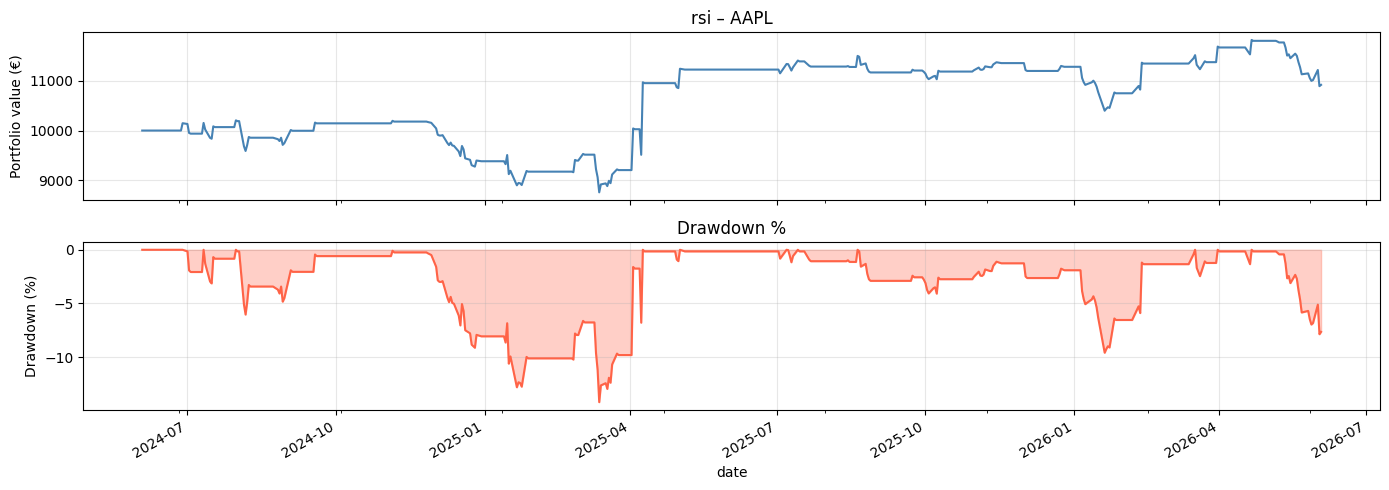


Best for SHEL.L: rsi  Sharpe=-0.22


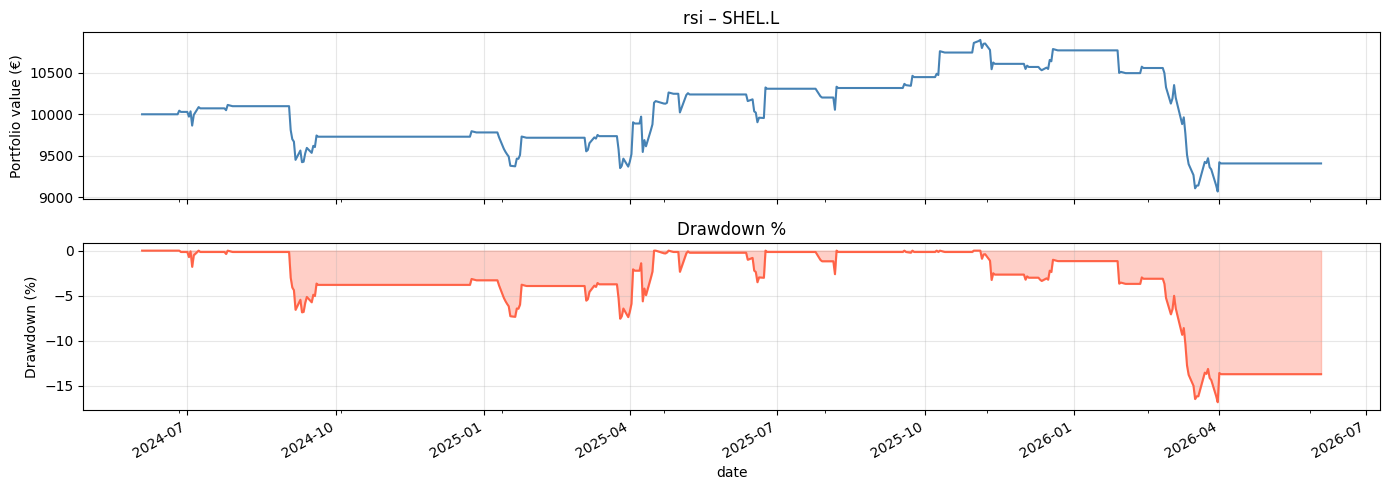

In [8]:
# Equity curve for best Sharpe strategy on each ticker
best = results_df['sharpe_ratio'].groupby(level='ticker').idxmax()
for ticker, (strat_name, _) in best.items():
    strategy = STRATEGY_REGISTRY[strat_name]()
    result = engine.run(strategy, data[ticker], ticker=ticker)
    print(f'\nBest for {ticker}: {strat_name}  Sharpe={result.metrics["sharpe_ratio"]:.2f}')
    result.plot()

In [9]:
# Walk-forward test on a single strategy
from strategies import MACrossStrategy

strat = MACrossStrategy(fast=10, slow=30)
folds = engine.run_walk_forward(strat, data['AAPL'], n_splits=5)

fold_metrics = pd.DataFrame([f.metrics for f in folds], index=[f'Fold {i+1}' for i in range(len(folds))])
fold_metrics[['ann_return', 'sharpe_ratio', 'max_drawdown']]

,ann_return,sharpe_ratio,max_drawdown
Fold 1,-0.4069,-2.7073,-0.2192
Fold 2,-0.3437,-1.7789,-0.2265
Fold 3,-0.3151,-1.6388,-0.1918
Fold 4,0.2328,1.5220,-0.0645
Fold 5,0.4947,2.3103,-0.0612
